In [5]:
import pandas as pd
import numpy as np 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv('Titanic-Dataset.csv')

In [8]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
113,114,0,3,"Jussila, Miss. Katriina",female,20.0,1,0,4136,9.8250,NaN,S
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,NaN,S
756,757,0,3,"Carlsson, Mr. August Sigfrid",male,28.0,0,0,350042,7.7958,NaN,S
682,683,0,3,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,NaN,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,NaN,0,1,113505,55.0000,E33,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (712, 11), X_test: (179, 11)
y_train: (712,), y_test: (179,)


In [17]:
import matplotlib.pyplot as plt

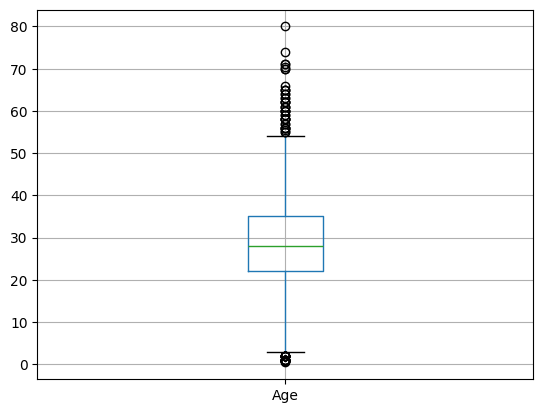

In [18]:
df.boxplot(column="Age")
plt.show()

In [19]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
IQR=Q3-Q1

df=df[~((df["Age"]<(Q1-1.5*IQR))|
        (df["Age"]>(Q3+1.5*IQR)))]
print("Shape after outlier removal:",df.shape)
        

Shape after outlier removal: (825, 12)


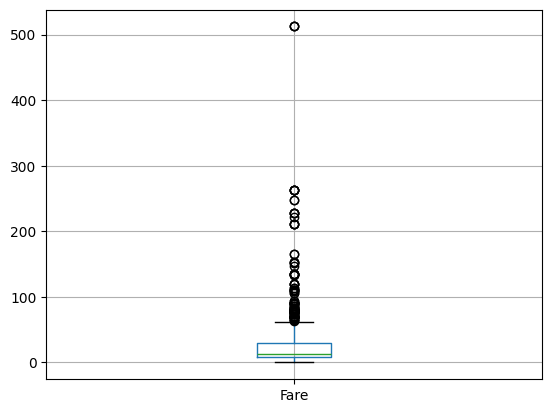

In [20]:
df.boxplot(column="Fare")
plt.show()

In [21]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df["Fare"] < (Q1 - 3 * IQR)) |
          (df["Fare"] > (Q3 + 3 * IQR)))]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (778, 12)


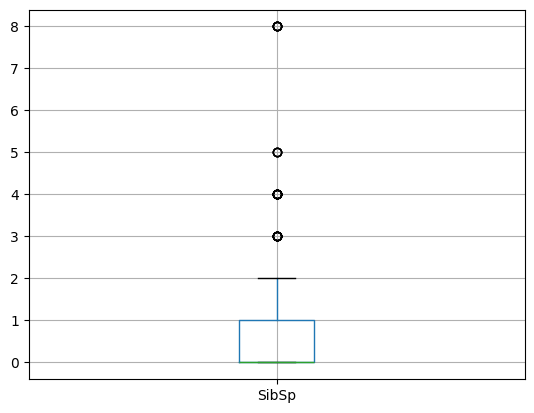

In [22]:
df.boxplot(column="SibSp")
plt.show()

In [23]:
Q1 = df["SibSp"].quantile(0.25)
Q3 = df["SibSp"].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df["SibSp"] < (Q1 - 3 * IQR)) |
          (df["SibSp"] > (Q3 + 3 * IQR)))]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (767, 12)


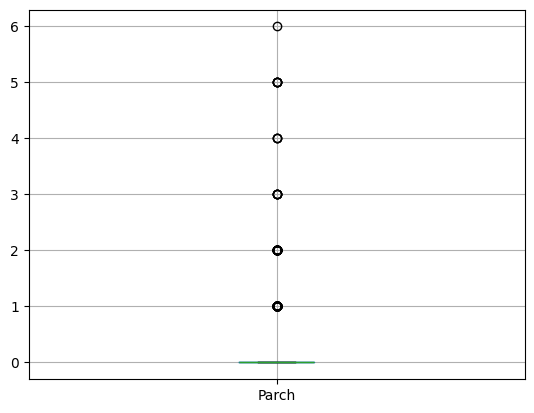

In [24]:
df.boxplot(column="Parch")
plt.show()

In [25]:
Q1 = df["Parch"].quantile(0.25)
Q3 = df["Parch"].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df["Parch"] < (Q1 - 3 * IQR)) |
          (df["Parch"] > (Q3 + 3 * IQR)))]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (620, 12)


In [26]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# Label Encoding for binary column
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# One-Hot Encoding for Embarked
nominal_cols = ['Embarked']
for col in nominal_cols:
    ohe = OneHotEncoder(sparse_output=False, drop='first')
    encoded = ohe.fit_transform(df[[col]])
    encoded_df = pd.DataFrame(encoded,
                               columns=ohe.get_feature_names_out([col]),
                               index=df.index)
    df = pd.concat([df, encoded_df], axis=1)
    df.drop(columns=[col], inplace=True)

df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], inplace=True, errors='ignore')

print(df.head())
print(df.shape)
print(df.info())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500         0.0         1.0
1         1       1    0  38.0      1      0  71.2833         0.0         0.0
2         1       3    0  26.0      0      0   7.9250         0.0         1.0
3         1       1    0  35.0      1      0  53.1000         0.0         1.0
4         0       3    1  35.0      0      0   8.0500         0.0         1.0
(620, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 620 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    620 non-null    int64  
 1   Pclass      620 non-null    int64  
 2   Sex         620 non-null    int64  
 3   Age         620 non-null    float64
 4   SibSp       620 non-null    int64  
 5   Parch       620 non-null    int64  
 6   Fare        620 non-null    float64
 7   Embarked_Q  620 non-null    float64
 8   Embarked_

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Age → MinMaxScaler (clean, bounded after IQR outlier removal)
minmax = MinMaxScaler()
df[['Age']] = minmax.fit_transform(df[['Age']])

# Fare → RobustScaler (skewed distribution even after outlier removal)
robust = RobustScaler()
df[['Fare']] = robust.fit_transform(df[['Fare']])

# SibSp → MinMaxScaler (small discrete range 0-8)
minmax2 = MinMaxScaler()
df[['SibSp']] = minmax2.fit_transform(df[['SibSp']])

# Parch → MinMaxScaler (small discrete range 0-6)
minmax3 = MinMaxScaler()
df[['Parch']] = minmax3.fit_transform(df[['Parch']])

# confirm
print(df[['Age', 'Fare', 'SibSp', 'Parch']].head())

        Age      Fare     SibSp  Parch
0  0.346939 -0.137606  0.333333    0.0
1  0.673469  3.778552  0.333333    0.0
2  0.428571 -0.096324  0.000000    0.0
3  0.612245  2.666495  0.333333    0.0
4  0.612245 -0.088679  0.000000    0.0


In [28]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (496, 8), X_test: (124, 8)
y_train: (496,), y_test: (124,)


In [29]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8467741935483871
